# Embeddings — the geometry of meaning

**Notebook 04 · Phase 2 (Retrieval foundations)** · Stack: `langchain-openai` (API) + `sentence-transformers` (local)

Chunking gave us retrieval-sized text. **Embeddings** turn that text into *dense vectors* —
points in a high-dimensional space where **distance = difference in meaning**. This is the
engine that makes semantic search possible.

This notebook proves four things:

1. **Embeddings encode meaning as geometry** — paraphrases land close together; unrelated
   text lands far apart.
2. **The iron rule: index-time and query-time must use the *same* model.** Mix models and
   retrieval silently breaks.
3. **Model choice matters** — general vs. multilingual vs. long-context, and dimensionality
   vs. cost.
4. **When to fine-tune** for a domain.

We use a **hybrid** setup: OpenAI embeddings (managed API) for the core demos, plus small
**local** `sentence-transformers` models to show self-hosted and multilingual behavior.

## 0. Install dependencies

Run first. Installs into the active kernel (idempotent). Restart the kernel once after a
fresh install. *(The local models download on first use: ~90 MB + ~420 MB.)*

In [1]:
# Install dependencies into the ACTIVE kernel (idempotent).
%pip install -q \
    "numpy<2" \
    langchain-openai python-dotenv \
    sentence-transformers scikit-learn matplotlib tiktoken
print("✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /Users/mohamednoordeenalaudeen/Documents/GenAI-2026/.venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
✅ Dependencies ready. If this was a fresh install, restart the kernel, then re-run.


## 1. Setup

OpenAI embeddings via `langchain-openai`; local models via `sentence-transformers`. We use
`text-embedding-3-small` (1536-dim) and `-3-large` (3072-dim) on the API side, and two small
local models: an **English-only** one and a **multilingual** one.

In [2]:
import warnings, os
warnings.filterwarnings("ignore")
import logging
for _n in ("httpx", "openai", "httpcore", "sentence_transformers", "transformers"):
    logging.getLogger(_n).setLevel(logging.ERROR)
from pathlib import Path
from dotenv import load_dotenv
import numpy as np

load_dotenv(Path.cwd().parent / ".env")

from langchain_openai import OpenAIEmbeddings
oai_small = OpenAIEmbeddings(model="text-embedding-3-small")   # 1536 dims
oai_large = OpenAIEmbeddings(model="text-embedding-3-large")   # 3072 dims

print("OPENAI_API_KEY set:", bool(os.getenv("OPENAI_API_KEY")))
print("OpenAI models: text-embedding-3-small (1536d), text-embedding-3-large (3072d)")

OPENAI_API_KEY set: True
OpenAI models: text-embedding-3-small (1536d), text-embedding-3-large (3072d)


In [3]:
from sentence_transformers import SentenceTransformer

# Downloads on first run, then cached locally.
en_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")                    # English-only
ml_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")  # multilingual
print("local: all-MiniLM-L6-v2 (", en_model.get_sentence_embedding_dimension(), "d) |",
      "paraphrase-multilingual-MiniLM-L12-v2 (", ml_model.get_sentence_embedding_dimension(), "d)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


local: all-MiniLM-L6-v2 ( 384 d) | paraphrase-multilingual-MiniLM-L12-v2 ( 384 d)


> **A note on model choice (mid-2026):** `all-MiniLM-L6-v2` (2021, 22M params) and `paraphrase-multilingual-MiniLM-L12-v2` are used here because they're tiny, fast, and download in seconds — ideal for a live demo, not a production recommendation. If you're choosing a **local/self-hosted** embedding model for real use today, start from **BGE-M3** (BAAI, MIT license — the de facto default for multilingual + hybrid dense/sparse retrieval) or **Qwen3-Embedding** (Apache 2.0 — currently tops the open-weight MTEB leaderboard). Same `sentence-transformers` API, just a different `model_name` string — everything in this notebook applies unchanged.


### Helper — cosine similarity

Cosine similarity measures the angle between two vectors: **1.0 = identical direction
(same meaning)**, **0 = unrelated**, **negative = opposed**. It's the standard metric for
comparing embeddings.

In [4]:
def cos(a, b) -> float:
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

# convenience: embed with OpenAI (returns python lists)
def oai_embed(texts, model=oai_small):
    return model.embed_documents(texts) if isinstance(texts, list) else model.embed_query(texts)

## 2. Embeddings are the geometry of meaning

Embed a few sentences and look at (a) the raw vector and (b) how close the meanings are.
Two paraphrases of the *same* idea should be far more similar than an unrelated sentence,
**even when they share no words**.

In [5]:
sentences = [
    "How do I cancel my subscription?",           # 0
    "What is the process to terminate my plan?",   # 1  (paraphrase of 0, no shared keywords)
    "The warehouse migration reduced throughput.", # 2  (unrelated)
]
vecs = oai_small.embed_documents(sentences)

v = np.array(vecs[0])
print(f"one embedding: dim={v.shape[0]}, first 8 values = {np.round(v[:8], 4)}")
print(f"\ncos(0,1) paraphrases  = {cos(vecs[0], vecs[1]):.3f}   <- high (same meaning)")
print(f"cos(0,2) unrelated    = {cos(vecs[0], vecs[2]):.3f}   <- low  (different meaning)")

one embedding: dim=1536, first 8 values = [ 0.0215  0.0159 -0.0043  0.0019 -0.0496  0.024  -0.0259  0.0502]

cos(0,1) paraphrases  = 0.598   <- high (same meaning)
cos(0,2) unrelated    = 0.088   <- low  (different meaning)


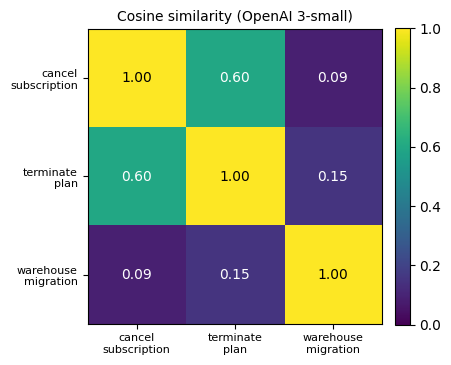

In [6]:
# Visualize the full similarity matrix as a heatmap.
import matplotlib.pyplot as plt

labels = ["cancel\nsubscription", "terminate\nplan", "warehouse\nmigration"]
M = np.array([[cos(a, b) for b in vecs] for a in vecs])

fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(M, cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(labels, fontsize=8)
ax.set_yticks(range(3)); ax.set_yticklabels(labels, fontsize=8)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center",
                color="white" if M[i, j] < 0.6 else "black", fontsize=10)
ax.set_title("Cosine similarity (OpenAI 3-small)", fontsize=10)
fig.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

The two paraphrases (top-left block) are highly similar despite **zero shared keywords** —
that's semantic matching. The unrelated sentence sits far from both. This geometry is
exactly what a vector database searches over.

## 3. The iron rule: same model for index *and* query

Embeddings are only comparable **within the same model's vector space**. Index your corpus
with model A and embed queries with model B, and the vectors live in different spaces — the
"nearest" neighbor becomes meaningless. Two ways this breaks:

In [7]:
corpus = [
    "Refunds are processed within 5 business days.",
    "Standard shipping takes 3 to 5 business days.",
    "Employees get a $45 monthly home-internet stipend.",
]
query = "How long until I get my money back?"

# CORRECT: index and query with the SAME model (3-small)
c_small = oai_small.embed_documents(corpus)
q_small = oai_small.embed_query(query)
best = int(np.argmax([cos(q_small, c) for c in c_small]))
print("SAME model (3-small → 3-small):")
print(f"   best match = corpus[{best}]: {corpus[best]!r}  ✅ (the refund line)")

# BROKEN #1: query embedded with a different-dimension model
q_large = oai_large.embed_query(query)   # 3072 dims vs corpus 1536 dims
try:
    _ = [cos(q_large, c) for c in c_small]
except Exception as e:
    print("\nDIFFERENT model, different dims (3-large query vs 3-small index):")
    print("   ->", type(e).__name__, "- vectors aren't even the same length; cannot compare ❌")

SAME model (3-small → 3-small):
   best match = corpus[0]: 'Refunds are processed within 5 business days.'  ✅ (the refund line)



DIFFERENT model, different dims (3-large query vs 3-small index):
   -> ValueError - vectors aren't even the same length; cannot compare ❌


In [8]:
# BROKEN #2: same *dimension*, different *model* = incompatible space.
# Embed the IDENTICAL sentence with two different 384-dim models and compare.
text = "Refunds are processed within 5 business days."
v_en = en_model.encode([text])[0]   # English-only model
v_ml = ml_model.encode([text])[0]   # multilingual model (also 384 dims)
print("Same 384 dims, SAME sentence, DIFFERENT models:")
print(f"   cos(en-model vs ml-model) = {cos(v_en, v_ml):.3f}   <- identical text, yet nearly unrelated ❌")
print(f"   cos(en-model vs en-model) = {cos(v_en, en_model.encode([text])[0]):.3f}   <- same model = perfect ✅")
print("\nMatching dimensions do NOT make two spaces comparable — only using the same model does.")

Same 384 dims, SAME sentence, DIFFERENT models:
   cos(en-model vs ml-model) = 0.230   <- identical text, yet nearly unrelated ❌
   cos(en-model vs en-model) = 1.000   <- same model = perfect ✅

Matching dimensions do NOT make two spaces comparable — only using the same model does.


## 4. Choosing an embedding model

No single model is best. The axes that matter: **language coverage**, **context window**,
**dimensionality/cost**, and **domain fit**.

### 4a. Multilingual vs. English-only

Embed the same sentence in English, French, and Hindi. A **multilingual** model places
translations close together; an **English-only** model treats them as noise.

In [9]:
from sentence_transformers import util
en = "The contract can be terminated with sixty days written notice."
fr = "Le contrat peut être résilié avec un préavis écrit de soixante jours."
hi = "अनुबंध को साठ दिनों के लिखित नोटिस के साथ समाप्त किया जा सकता है।"
unrelated = "I really enjoy eating pizza on weekends."

def sim(model, a, b):
    ea, eb = model.encode([a, b]); return float(util.cos_sim(ea, eb))

print("English-only model (all-MiniLM-L6-v2):")
print(f"   EN↔FR {sim(en_model, en, fr):+.3f} | EN↔HI {sim(en_model, en, hi):+.3f} | EN↔unrelated {sim(en_model, en, unrelated):+.3f}   ❌ can't match translations")
print("\nMultilingual model (paraphrase-multilingual-MiniLM-L12-v2):")
print(f"   EN↔FR {sim(ml_model, en, fr):+.3f} | EN↔HI {sim(ml_model, en, hi):+.3f} | EN↔unrelated {sim(ml_model, en, unrelated):+.3f}   ✅ translations cluster")
print(f"\nOpenAI 3-small (managed, also multilingual): EN↔FR {cos(oai_small.embed_query(en), oai_small.embed_query(fr)):+.3f}")

English-only model (all-MiniLM-L6-v2):
   EN↔FR -0.028 | EN↔HI -0.052 | EN↔unrelated +0.023   ❌ can't match translations

Multilingual model (paraphrase-multilingual-MiniLM-L12-v2):


   EN↔FR +0.859 | EN↔HI +0.945 | EN↔unrelated -0.019   ✅ translations cluster



OpenAI 3-small (managed, also multilingual): EN↔FR +0.789


### 4b. Context window (long-context)

An embedding model can only "see" up to its max token limit; text beyond that is **silently
truncated**. If key information sits past the limit, it never enters the vector. We hide a
passphrase at the *end* of a long document and query for it.

In [10]:
import tiktoken
enc = tiktoken.get_encoding("cl100k_base")

filler = ("Northwind Logistics operates regional distribution centers. " * 120)
long_doc = filler + " The secret passphrase for the vault is ZEBRA-42."
q = "What is the secret passphrase for the vault?"
print("long_doc tokens:", len(enc.encode(long_doc)),
      "| all-MiniLM max_seq_length:", en_model.max_seq_length, "tokens")

# Local small model truncates -> never sees the passphrase at the end
local_sim = float(util.cos_sim(en_model.encode([q]), en_model.encode([long_doc])))
# OpenAI 3-small (8191-token window) encodes the whole doc, passphrase included
oai_sim = cos(oai_small.embed_query(q), oai_small.embed_query(long_doc))
print(f"\ncos(query, long_doc):")
print(f"   all-MiniLM-L6-v2 (truncates ~256 tok): {local_sim:.3f}  <- passphrase cut off")
print(f"   OpenAI 3-small (8191 tok window):      {oai_sim:.3f}  <- passphrase retained")

long_doc tokens: 974 | all-MiniLM max_seq_length: 256 tokens



cos(query, long_doc):
   all-MiniLM-L6-v2 (truncates ~256 tok): -0.131  <- passphrase cut off
   OpenAI 3-small (8191 tok window):      0.333  <- passphrase retained


### 4c. Dimensionality vs. cost

Bigger vectors can encode more nuance but cost more RAM/storage in the vector DB. Matryoshka
models (OpenAI v3) let you **truncate** dimensions with graceful quality loss — a cheap lever.

**Production pattern:** don't just pick one dimension and stop — retrieve a wide candidate set with cheap truncated embeddings (e.g. 256-dim), then re-score just the top-K with the full-dimension embedding before returning results. You get most of the storage/speed win from truncation with almost none of the quality loss, since the expensive full-precision comparison only runs on a handful of candidates, not the whole index.

In [11]:
pair = ("How do I cancel my subscription?", "What is the process to terminate my plan?")

oai_1536 = OpenAIEmbeddings(model="text-embedding-3-large")                 # 3072 default
oai_256  = OpenAIEmbeddings(model="text-embedding-3-large", dimensions=256)  # Matryoshka truncation

full = [oai_1536.embed_query(pair[0]), oai_1536.embed_query(pair[1])]
trunc = [oai_256.embed_query(pair[0]),  oai_256.embed_query(pair[1])]
print(f"3-large  (dim={len(full[0])}):  paraphrase sim = {cos(*full):.3f}")
print(f"3-large  (dim={len(trunc[0])}, Matryoshka): paraphrase sim = {cos(*trunc):.3f}")
print("\n→ 12x smaller vectors retain most of the signal. Sweep dims vs recall on YOUR data.")

3-large  (dim=3072):  paraphrase sim = 0.560
3-large  (dim=256, Matryoshka): paraphrase sim = 0.591

→ 12x smaller vectors retain most of the signal. Sweep dims vs recall on YOUR data.


### 4d. Domain fit (when to fine-tune)

General models can miss domain jargon — distinct concepts may look similar, or synonyms may
look distant. When off-the-shelf recall lags on your corpus, **fine-tune** on your own
query→passage pairs (e.g. with `sentence-transformers`); see the embedding-selection guide in
`reference/`.

In [12]:
# Domain jargon: to a logistics team these are DIFFERENT things, but a general model
# may rate them highly similar because the surface language overlaps.
a = "What is the on-time delivery rate?"        # an operational KPI
b = "What is the perfect order rate?"           # a different KPI (accuracy+completeness+timeliness)
print(f"general model sim(on-time rate, perfect order rate) = {cos(oai_small.embed_query(a), oai_small.embed_query(b)):.3f}")
print("If these distinct KPIs score as near-identical, a general model will confuse them at")
print("retrieval time — a signal to fine-tune on labeled domain pairs (or add metadata filters).")

general model sim(on-time rate, perfect order rate) = 0.545
If these distinct KPIs score as near-identical, a general model will confuse them at
retrieval time — a signal to fine-tune on labeled domain pairs (or add metadata filters).


## 5. Summary

| Decision | Rule of thumb |
|----------|---------------|
| **Same model, index + query** | Non-negotiable. Different model = different space = broken retrieval. Version-lock it. |
| **Language** | Non-English or mixed corpus → a multilingual model (or OpenAI v3 / BGE-M3). |
| **Context window** | Model max tokens must exceed your chunk size, or the tail is truncated away. |
| **Dimensionality** | Bigger = more nuance but more RAM/cost; Matryoshka truncation trades a little quality for big savings. |
| **Domain fit** | General model weak on your jargon → fine-tune on labeled query→passage pairs. |

### What we proved
- Embeddings turn meaning into geometry — paraphrases cluster, unrelated text separates.
- Mixing models (different dims *or* just a different model at the same dims) breaks retrieval.
- Multilingual, long-context, dimensionality, and domain fit each change the right choice.

### Next
Embeddings need a home. Next: a **vector database** to index these vectors and do fast
nearest-neighbor search — plus retrieval and reranking on top.